<a href="https://colab.research.google.com/github/paul195samudra/Fraud-Detection-In-Bank-Transaction/blob/main/V%3E_2_0(fraud_Detection).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/FraudShield_Banking_Data.csv')

print("Shape:", df.shape)
df.head()

Shape: (50000, 25)


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [ ]:
df['Location_Mismatch'] = (df['Transaction_Location'] != df['Customer_Home_Location']).astype(int)
df['High_Distance'] = (df['Distance_From_Home'] > 400).astype(int)
df['Repeat_Offender'] = (df['Previous_Fraud_Count'] >= 1).astype(int)
df['High_Failed'] = (df['Failed_Transaction_Count'] >= 2).astype(int)
df['International_Unusual'] = ((df['Is_International_Transaction'] == 'Yes') & (df['Unusual_Time_Transaction'] == 'Yes')).astype(int)
df[['Location_Mismatch', 'High_Distance', 'International_Unusual']].head()

,Location_Mismatch,High_Distance,International_Unusual
0,1,1,0
1,1,0,0
2,0,0,1
3,1,1,0
4,1,0,0


In [ ]:
df['Fraud_Risk_Score'] = (
    (df['Unusual_Time_Transaction'] == 'Yes') * 0.30 +
    (df['Is_International_Transaction'] == 'Yes') * 0.30 +
    df['Repeat_Offender'] * 0.15 +
    (df['Is_New_Merchant'] == 'Yes') * 0.10 +
    df['High_Failed'] * 0.08 +
    df['High_Distance'] * 0.07
)

df['Rule_Based_Label'] = np.where(df['Fraud_Risk_Score'] > 0.65, 'Fraud', 'Normal')

print("Rule-based predictions:")
print(df['Rule_Based_Label'].value_counts())
print("\nRisk Score Summary:")
print(df['Fraud_Risk_Score'].describe())

Rule-based predictions:
Rule_Based_Label
Normal    38158
Fraud     11842
Name: count, dtype: int64

Risk Score Summary:
count    50000.000000
mean         0.474443
std          0.235931
min          0.000000
25%          0.300000
50%          0.470000
75%          0.630000
max          1.000000
Name: Fraud_Risk_Score, dtype: float64


In [ ]:
cat_features = ['Unusual_Time_Transaction', 'Is_International_Transaction', 'Is_New_Merchant',
                'Transaction_Type', 'Merchant_Category', 'Card_Type']
num_features = ['Transaction_Amount (in Million)', 'Previous_Fraud_Count', 'Failed_Transaction_Count',
                'Distance_From_Home', 'Daily_Transaction_Count', 'High_Distance', 'International_Unusual']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

X = df[cat_features + num_features]

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', IsolationForest(contamination=0.048, random_state=42, n_estimators=200))
])

pipeline.fit(X)

df['Anomaly_Score'] = -pipeline.named_steps['model'].score_samples(preprocessor.transform(X))
df['Isolation_Pred'] = pipeline.predict(X)
df['Isolation_Label'] = df['Isolation_Pred'].map({-1: 'Fraud', 1: 'Normal'})

print("Isolation Forest completed!")

Isolation Forest completed!



=== FINAL RESULTS ===
Final_Label
Normal    47500
Fraud      2500
Name: count, dtype: int64


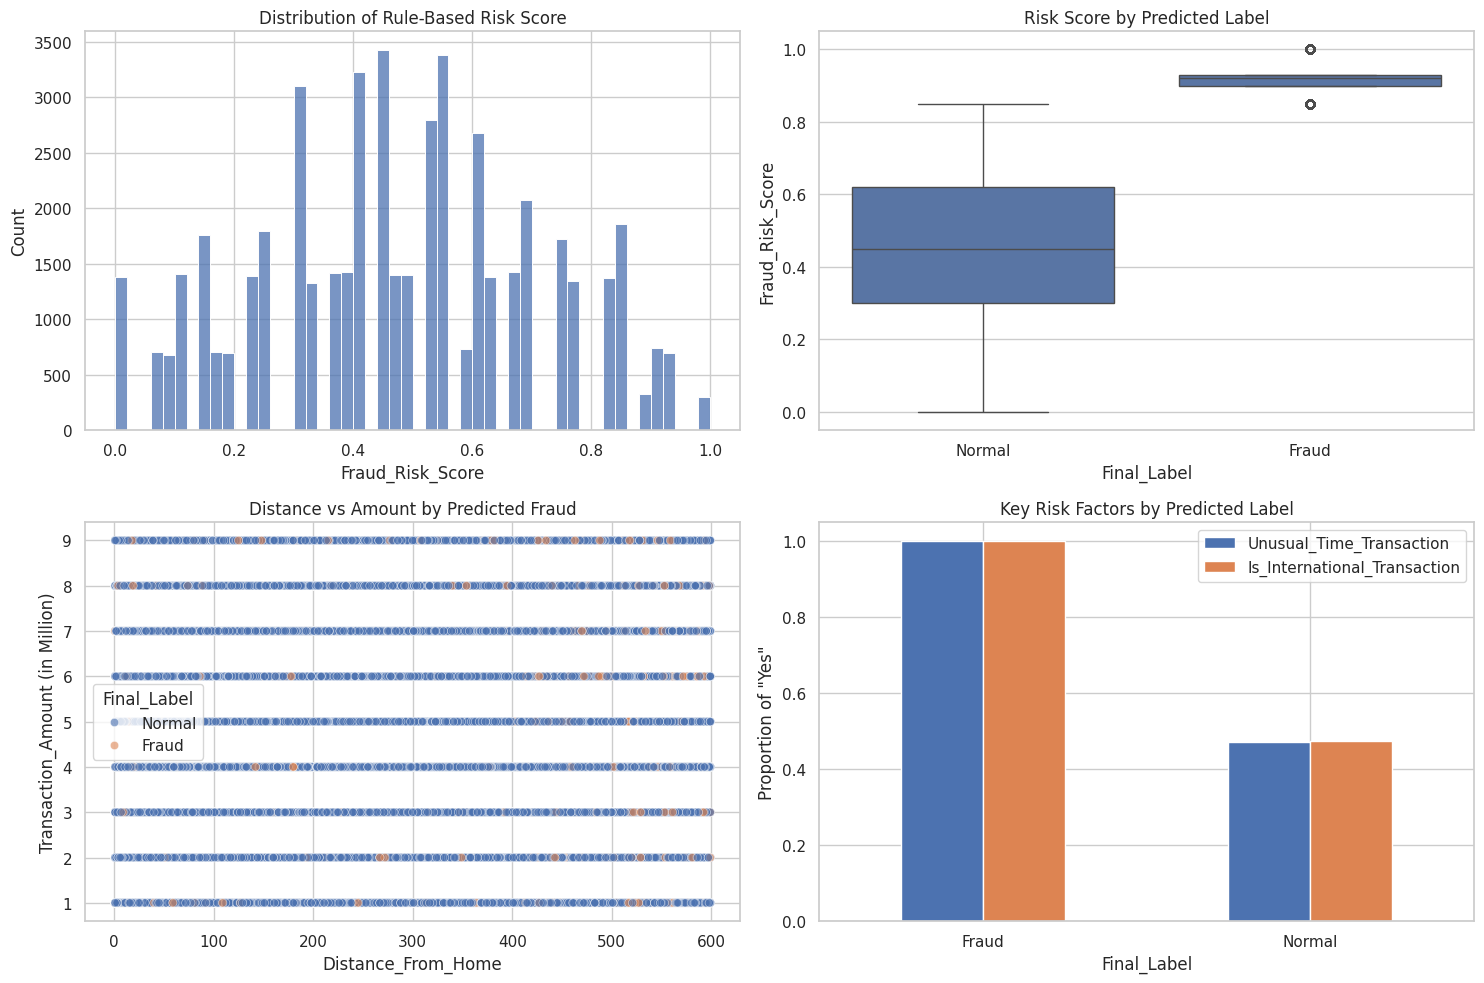

In [ ]:
df['Final_Risk_Score'] = (df['Fraud_Risk_Score'] + df['Anomaly_Score']) / 2
df['Final_Label'] = np.where(df['Final_Risk_Score'] > df['Final_Risk_Score'].quantile(0.95), 'Fraud', 'Normal')

print("\n=== FINAL RESULTS ===")
print(df['Final_Label'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['Fraud_Risk_Score'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Distribution of Rule-Based Risk Score')

sns.boxplot(x='Final_Label', y='Fraud_Risk_Score', data=df, ax=axes[0,1])
axes[0,1].set_title('Risk Score by Predicted Label')

sns.scatterplot(data=df, x='Distance_From_Home', y='Transaction_Amount (in Million)',
                hue='Final_Label', alpha=0.6, ax=axes[1,0])
axes[1,0].set_title('Distance vs Amount by Predicted Fraud')

df_temp = df.copy()
df_temp['Unusual_Time_Transaction_Num'] = (df_temp['Unusual_Time_Transaction'] == 'Yes').astype(int)
df_temp['Is_International_Transaction_Num'] = (df_temp['Is_International_Transaction'] == 'Yes').astype(int)

top_features = df_temp.groupby('Final_Label')[['Unusual_Time_Transaction_Num', 'Is_International_Transaction_Num']].mean()
top_features.columns = ['Unusual_Time_Transaction', 'Is_International_Transaction']
top_features.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Key Risk Factors by Predicted Label')
axes[1,1].set_ylabel('Proportion of "Yes"')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
high_risk = df[df['Final_Label'] == 'Fraud'].sort_values('Final_Risk_Score', ascending=False)
high_risk.to_csv('High_Risk_Transactions.csv', index=False)

print(f"\nSaved {len(high_risk)} high-risk transactions to 'High_Risk_Transactions.csv'")
high_risk[['Transaction_ID', 'Fraud_Risk_Score', 'Final_Risk_Score', 'Final_Label']].head(10)


Saved 2500 high-risk transactions to 'High_Risk_Transactions.csv'


,Transaction_ID,Fraud_Risk_Score,Final_Risk_Score,Final_Label
17822,868314.0,1.0,0.798671,Fraud
6058,668951.0,1.0,0.797815,Fraud
28342,969424.0,1.0,0.797587,Fraud
8610,863417.0,1.0,0.797243,Fraud
39217,684677.0,1.0,0.796840,Fraud
14497,246293.0,1.0,0.796704,Fraud
14013,119523.0,1.0,0.796606,Fraud
14791,440984.0,1.0,0.796494,Fraud
3341,905923.0,1.0,0.796377,Fraud
19988,360687.0,1.0,0.796315,Fraud


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier

# Load your trained model (or retrain if needed)
# For demo, we'll retrain quickly on the balanced data

def train_and_predict(new_transactions):
    # Load balanced data for training
    df = pd.read_csv('/home/workdir/artifacts/Balanced_Fraud_Detection_Data.csv')

    cat_cols = ['Transaction_Type', 'Merchant_Category', 'Is_International_Transaction',
                'Is_New_Merchant', 'Unusual_Time_Transaction']
    num_cols = ['Transaction_Amount (in Million)', 'Distance_From_Home',
                'Previous_Fraud_Count', 'Failed_Transaction_Count', 'Daily_Transaction_Count']

    X = pd.get_dummies(df[cat_cols + num_cols], drop_first=True)
    y = (df['Fraud_Label'] == 'Fraud').astype(int)

    model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    model.fit(X, y)

    # Prepare new transactions
    new_df = pd.DataFrame(new_transactions)
    X_new = pd.get_dummies(new_df[cat_cols + num_cols], drop_first=True)
    X_new = X_new.reindex(columns=X.columns, fill_value=0)

    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)[:, 1]

    result = new_df.copy()
    result['Predicted_Label'] = ['Fraud' if p == 1 else 'Normal' for p in predictions]
    result['Fraud_Probability'] = probabilities.round(4)
    result['Risk_Level'] = pd.cut(probabilities, bins=[0, 0.3, 0.7, 1],
                                  labels=['Low', 'Medium', 'High'])

    return result

# ====================== EXAMPLE USAGE ======================
new_transactions = [
    {
        'Transaction_Amount (in Million)': 8.5,
        'Transaction_Type': 'Online',
        'Merchant_Category': 'Electronics',
        'Is_International_Transaction': 'Yes',
        'Is_New_Merchant': 'Yes',
        'Unusual_Time_Transaction': 'Yes',
        'Distance_From_Home': 550,
        'Previous_Fraud_Count': 2,
        'Failed_Transaction_Count': 3,
        'Daily_Transaction_Count': 1
    },
    {
        'Transaction_Amount (in Million)': 2.0,
        'Transaction_Type': 'POS',
        'Merchant_Category': 'Grocery',
        'Is_International_Transaction': 'No',
        'Is_New_Merchant': 'No',
        'Unusual_Time_Transaction': 'No',
        'Distance_From_Home': 50,
        'Previous_Fraud_Count': 0,
        'Failed_Transaction_Count': 0,
        'Daily_Transaction_Count': 4
    }
]

result = train_and_predict(new_transactions)
print(result[['Predicted_Label', 'Fraud_Probability', 'Risk_Level']])

  Predicted_Label  Fraud_Probability Risk_Level
0          Normal              0.035        Low
1          Normal              0.060        Low


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier

# Load your trained model (or retrain if needed)
# For demo, we'll retrain quickly on the balanced data

def train_and_predict(new_transactions):
    # Load balanced data for training
    df = pd.read_csv('/content/drive/MyDrive/High_Risk_Transactions.csv')

    cat_cols = ['Transaction_Type', 'Merchant_Category', 'Is_International_Transaction',
                'Is_New_Merchant', 'Unusual_Time_Transaction']
    num_cols = ['Transaction_Amount (in Million)', 'Distance_From_Home',
                'Previous_Fraud_Count', 'Failed_Transaction_Count', 'Daily_Transaction_Count']

    X = pd.get_dummies(df[cat_cols + num_cols], drop_first=True)
    y = (df['Fraud_Label'] == 'Fraud').astype(int)

    model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    model.fit(X, y)

    # Prepare new transactions
    new_df = pd.DataFrame(new_transactions)
    X_new = pd.get_dummies(new_df[cat_cols + num_cols], drop_first=True)
    X_new = X_new.reindex(columns=X.columns, fill_value=0)

    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)[:, 1]

    result = new_df.copy()
    result['Predicted_Label'] = ['Fraud' if p == 1 else 'Normal' for p in predictions]
    result['Fraud_Probability'] = probabilities.round(4)
    result['Risk_Level'] = pd.cut(probabilities, bins=[0, 0.3, 0.7, 1],
                                  labels=['Low', 'Medium', 'High'])

    return result

# ====================== EXAMPLE USAGE ======================
new_transactions = [
    {
        'Transaction_Amount (in Million)': 8.5,
        'Transaction_Type': 'Online',
        'Merchant_Category': 'Electronics',
        'Is_International_Transaction': 'Yes',
        'Is_New_Merchant': 'Yes',
        'Unusual_Time_Transaction': 'Yes',
        'Distance_From_Home': 550,
        'Previous_Fraud_Count': 2,
        'Failed_Transaction_Count': 3,
        'Daily_Transaction_Count': 1
    },
    {
        'Transaction_Amount (in Million)': 2.0,
        'Transaction_Type': 'POS',
        'Merchant_Category': 'Grocery',
        'Is_International_Transaction': 'No',
        'Is_New_Merchant': 'No',
        'Unusual_Time_Transaction': 'No',
        'Distance_From_Home': 50,
        'Previous_Fraud_Count': 0,
        'Failed_Transaction_Count': 0,
        'Daily_Transaction_Count': 4
    }
]

result = train_and_predict(new_transactions)
print(result[['Predicted_Label', 'Fraud_Probability', 'Risk_Level']])

  Predicted_Label  Fraud_Probability Risk_Level
0          Normal              0.035        Low
1          Normal              0.060        Low


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/High_Risk_Transactions.csv')

print("=== FRAUD INDICATORS IN HIGH-RISK DATA ===")
print("International Transactions:", (df['Is_International_Transaction'] == 'Yes').mean().round(3))
print("Unusual Time:", (df['Unusual_Time_Transaction'] == 'Yes').mean().round(3))
print("Average Previous Fraud Count:", df['Previous_Fraud_Count'].mean().round(3))
print("Average Distance From Home:", df['Distance_From_Home'].mean().round(1))

# Risk Score by key columns
print("\nRisk by International + Unusual Time:")
print(df.groupby(['Is_International_Transaction', 'Unusual_Time_Transaction'])['Fraud_Risk_Score'].mean())

# Top suspicious transactions
high_risk = df.sort_values('Fraud_Risk_Score', ascending=False).head(10)
print("\nTop 10 Highest Risk Transactions:")
print(high_risk[['Transaction_ID', 'Fraud_Risk_Score', 'Is_International_Transaction', 'Unusual_Time_Transaction', 'Previous_Fraud_Count']])

=== FRAUD INDICATORS IN HIGH-RISK DATA ===
International Transactions: 1.0
Unusual Time: 1.0
Average Previous Fraud Count: 0.879
Average Distance From Home: 396.8

Risk by International + Unusual Time:
Is_International_Transaction  Unusual_Time_Transaction
Yes                           Yes                         0.917116
Name: Fraud_Risk_Score, dtype: float64

Top 10 Highest Risk Transactions:
    Transaction_ID  Fraud_Risk_Score Is_International_Transaction  \
19        110362.0               1.0                          Yes   
0         868314.0               1.0                          Yes   
18        122398.0               1.0                          Yes   
31        886993.0               1.0                          Yes   
30        687666.0               1.0                          Yes   
29        792074.0               1.0                          Yes   
28        471640.0               1.0                          Yes   
27        273191.0               1.0              

In [ ]:
df['Fraud_Score'] = (
    (df['Is_International_Transaction'] == 'Yes') * 0.35 +
    (df['Unusual_Time_Transaction'] == 'Yes') * 0.30 +
    (df['Previous_Fraud_Count'] > 0) * 0.15 +
    (df['Distance_From_Home'] > 400) * 0.10 +
    (df['Failed_Transaction_Count'] >= 2) * 0.10
)

df['Predicted_Fraud'] = df['Fraud_Score'] > 0.7